# Reproducing some results of the PhD talk

In this sandbox notebook is joint to get started with **GlobalGradVarRed** and **Jacques** acquisition functions.

Here, you will be able to reduce some results presented during the PhD Talk : **Gradient-based Active Learning with Gaussian Processes for Global Sensitivity Analysis**

- Multi-output Jacques on the IshigamiBranin benchmark function

As you may not want to re-run all the Active Learning loop, attached the result of the same code runned on the **PMCS2I Newton** cluster (Pôle de Modélisation et de Calcul en Sciences de l'Ingénieur de l'Information) from Centrale Lyon.

In [1]:
from utils.model import GP
from utils.acquisition import Jacques
from utils.util import draw_samples

from botorch.utils.sampling import draw_sobol_samples
from botorch.optim import optimize_acqf
from botorch.test_functions.synthetic import Branin

import matplotlib.pyplot as plt
import torch
import numpy as np

from sklearn.metrics import r2_score

import pickle
from pathlib import Path

import warnings
from tqdm.rich import tqdm
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

device = torch.device("cpu")
dtype = torch.float64

In [2]:
#To have great plots as in the presentation ;)

def _hex(h):
    return tuple(int(h.lstrip("#")[i:i+2], 16) / 255 for i in (0, 2, 4))

pal_jacques=_hex("#004e3f")
pal_sobol =_hex("#ec6739")
pal_fill_j=_hex("#007722")
pal_fill_s=_hex("#cfa03c")
pal_text=_hex("#252525")

plt.rcdefaults()
plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.labelsize":  12,
    "axes.titlesize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "legend.frameon":  False,
    "axes.grid":       True,
    "grid.alpha":      0.25,
    "grid.color":      "#b0b0b0",
    "axes.linewidth":  0.9,
    "axes.edgecolor":  pal_text,
    "xtick.color":     pal_text,
    "ytick.color":     pal_text,
    "axes.axisbelow":  True,
})

def _band(ax, x, mean, std, color_line, color_fill, marker="o", logy=False):
    lower = np.maximum(mean - std, 1e-12) if logy else mean - std
    ax.fill_between(x, lower, mean + std, alpha=0.18, color=color_fill, linewidth=0)
    ax.plot(x, mean, color=color_line, linewidth=2.2,
            marker=marker, markersize=4.5, markevery=5, clip_on=False)
    if logy:
        ax.set_yscale("log")

def _style(ax, title, ylabel, show_xlabel=True, fontsize = 12):
    ax.set_title(title, fontweight="bold", color=pal_text, pad=8, fontsize=fontsize+1)
    if show_xlabel:
        ax.set_xlabel("Number of added points", color=pal_text, fontsize=fontsize)
    ax.set_ylabel(ylabel, color=pal_text, fontsize=fontsize)
    for sp in ax.spines.values():
        sp.set_color(pal_text)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=pal_text, length=4, width=0.9)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))

# Branin 1D

A little *tuto* to run classical AL strategies based on **BoTorch** framework.

First, how do the **GP** class works ? 

From it you can, based on **GPyTorch** and **BoTorch** :
- Construct Single (model_type = "independent") or Multi-output (model_type = "mo_indep")
- Prediction via **predict** (return the MVN posterior with return_posterior = True)
- Gradient posterior : return the Gradient (Jacobian in case of MO) Posterior of the GP for a test set **X**. It handles batched evaluation.
- Fantasy conditionning : **fantasize** as described in BoTorch (Sobol-sequence quantization of the posterior - differnt from Kriging believer).
- Overall, it automatically handles the **MinMaxScaling** (set all input to $[0,1]^d$) and **Normalisation** (set all output with zero mean, unit std.) When calling *.fit*, *.predict*, *$\texttt{*.grad_posterior* and *.fantasize*, it expects data in original scale, then set them to the normalized space. The returned information will be set back to the original space. If you don't want such things (but warning GP are sensitivitives 🥴), set in init **no_std_norm =True**.

In [3]:
torch.manual_seed(69009) # Seed for reproctuctible ! Lyon gteat city.
np.random.seed(69009)

In [4]:
problem = Branin() #Init the test function : classical Branin

In [5]:
X = draw_samples(dists = [{"type": "unif", "a": 0., "b": 1.}]*2, n=30, q=1, seed = 69130).squeeze(1)
Y = problem(X).unsqueeze(1)

Xtest = draw_samples(dists = [{"type": "unif", "a": 0., "b": 1.}]*2, n=100, q=1, seed = 2742).squeeze(1)
Ytest = problem.evaluate_true(Xtest).unsqueeze(1) 

In [ ]:
model = GP(model_type ="independent", noise = False).fit(X, Y) # You fit the model via .fit(X, Y, verbose)

[GP.fit] trained from scratch: n=30, model_type=independent, noise=False, no_std_norm=False


In [ ]:
dist_pred = model.predict(Xtest, return_posterior = True) #To obtain prediction MVN, or raw without calling return_posterior

In [ ]:
print("Q^2 :", r2_score(Ytest, dist_pred.mean.detach().squeeze(0).squeeze(0))) #GReat =)

Q^2 : 0.9999938837723369


In [ ]:
grad_dists = model.grad_posterior(Xtest)[0] # MVN, [0] because it is a list of one element, one MVN.

**For Active learning on Jacques ($p=1$ case) :**

In [ ]:
N_Xs = 3000
d = 2
p = 1
N_init = 10 #5*d
N_AL_iter = 20 # 10*d, total 15d budget.
num_rep = 15 #Number of replication with different initial DoE.

In [133]:
torch.manual_seed(69009) # Seed for reproctuctible ! Lyon gteat city.
np.random.seed(69009)

problem = Branin(noise_std=0.05).to(dtype=dtype, device=device)

Xs = (
    draw_sobol_samples(bounds=problem.bounds, n=N_Xs, q=1, seed=69130) #Ecully very great city
    .squeeze(1).to(dtype=dtype, device=device)
)

In [ ]:
for s, seed in enumerate(tqdm(range(num_rep), desc="seeds")): #AL Loop, no more than 1min30 run
    
    torch.manual_seed(seed)
    np.random.seed(seed)

    X = (
        draw_sobol_samples(bounds=problem.bounds, n=N_init, q=1, seed=seed)
        .squeeze(1).to(dtype=dtype, device=device)
    )
    Y = problem(X)

    model = GP(model_type="mo_indep", noise=True).fit(X, Y, verbose = False)

    for i in tqdm(range(N_AL_iter), desc="AL iters", leave=False):

        acqf = Jacques(model=model, global_points=Xs, include_obs_noise=True)

        new_x, _ = optimize_acqf( #BFGS based optim, based on scipy.optim alg.
            acq_function=acqf,
            q=1,
            bounds=problem.bounds,
            raw_samples=512,
            num_restarts=40,
        )
        new_y = problem(new_x)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        model = GP(model_type="mo_indep", noise=True).fit(X, Y, verbose=False)

Output()

/Users/guerlainlambert/miniconda3/envs/these_311/lib/python3.11/site-packages/botorch/optim/optimize.py:796: 
RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)

/Users/guerlainlambert/miniconda3/envs/these_311/lib/python3.11/site-packages/botorch/optim/optimize.py:796: 
RuntimeWarning: Optimization failed on the second try, after generating a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)

/Users/guerlainlambert/miniconda3/envs/these_311/lib/python3.11/site-packages/botorch/optim/optimize.py:796: 
RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)

/Users/guerlainlambert/miniconda3/envs/these_311/lib/python3.11/site-packages/botorch/optim/optimize.py:796: 
RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)

What does the AL loop looks like ?

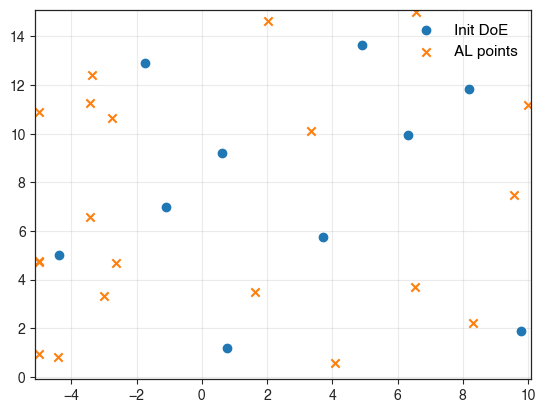

In [142]:
plt.scatter(X[:10, 0], X[:10, 1], label ="Init DoE")
plt.scatter(X[10:, 0], X[10:, 1], marker="x",label ="AL points")
plt.xlim(-5.1, 10.1)
plt.ylim(-0.1, 15.1)
plt.legend()

# Ishigami and Branin multi-outout

The experiments (Jacques and Sobol sequence) are available into the .pkl file attached to the repo.
Just load it to avoid runnning the method on your computer.

$ \mathcal{M}(x_1, x_2, x_3) = (\text{Ishigami}(x_1, x_2, x_3), \,\text{Branin}(x_1, x_2)) $

Load the data : 

In [ ]:
sauv_path_jacques_mo = Path("Jacques_MO_IshigamiBranin.pkl") #Codes from the run_jacques_mo_example.py 
sauv_path_sobol_mo   = Path("Sobol_MO_IshigamiBranin.pkl") 

with open(sauv_path_jacques_mo, "rb") as f:
    data_j = pickle.load(f)
    metrics_j = data_j["metrics"]

with open(sauv_path_sobol_mo, "rb") as f:
    data_s = pickle.load(f)
    metrics_s = data_s["metrics"]

In [ ]:
## True values computed on raw model (please trust me) :

true_dgsm_mo = np.array([[7.71958444,24.4999999 ,10.98730891],
       [2877.5490114 , 1032.01617131,0.]])

true_st_mo = np.array([[0.55758882, 0.44241112, 0.24368365],
        [0.74847094, 0.8642814 , 0.]])

true_st_agg = np.array([0.74747013, 0.86206949, 0.00127766])

true_var_f_mo = np.array([13.8446, 2626.6880])

In [ ]:
num_rep, n_snapshots = metrics_j["Q2_mean"].shape
N_init = 15
x_axis = np.arange(N_init, N_init + n_snapshots)

key_dgsm_j = "DGSM_raw" 
key_dgsm_s = "DGSM_raw"

# HEre is computed the per-output DGSM RMSE of shape (rep, al_iter, p)

rmse_dgsm_j = np.sqrt(
    np.mean((metrics_j[key_dgsm_j] - true_dgsm_mo[None, None]) ** 2, axis=-1)
)
rmse_dgsm_s = np.sqrt(
    np.mean((metrics_s[key_dgsm_s] - true_dgsm_mo[None, None]) ** 2, axis=-1)
)

# Same for S^T :

rmse_st_j = np.sqrt(
    np.mean((metrics_j["ST"] - true_st_mo[None, None]) ** 2, axis=-1)
)
rmse_st_s = np.sqrt(
    np.mean((metrics_s["ST"] - true_st_mo[None, None]) ** 2, axis=-1)
)

#RMSE for aggregated Sobol :

rmse_st_agg_j = np.sqrt(
    np.mean((metrics_j["ST_agg"] - true_st_agg[None, None]) ** 2, axis=-1)
)
rmse_st_agg_s = np.sqrt(
    np.mean((metrics_s["ST_agg"] - true_st_agg[None, None]) ** 2, axis=-1)
)

# RMSE for agg DGSM (stacked) (rep, snap)

rmse_dgsm_agg_j = rmse_dgsm_j.mean(axis=-1)
rmse_dgsm_agg_s = rmse_dgsm_s.mean(axis=-1)

# For Q^2 scores :

q2_j = metrics_j["Q2_mean"] # (rep, snap)
q2_s = metrics_s["Q2_mean"]
q2_raw_j = metrics_j["Q2"] # (rep, snap, p)
q2_raw_s = metrics_s["Q2"]

def summarise(arr):
    return arr.mean(0), arr.std(0)

# DGSM
dgsm_j_f1_mean, dgsm_j_f1_std = summarise(rmse_dgsm_j[:, :, 0])
dgsm_j_f2_mean, dgsm_j_f2_std = summarise(rmse_dgsm_j[:, :, 1])
dgsm_s_f1_mean, dgsm_s_f1_std = summarise(rmse_dgsm_s[:, :, 0])
dgsm_s_f2_mean, dgsm_s_f2_std = summarise(rmse_dgsm_s[:, :, 1])
dgsm_agg_j_mean, dgsm_agg_j_std = summarise(rmse_dgsm_agg_j)
dgsm_agg_s_mean, dgsm_agg_s_std = summarise(rmse_dgsm_agg_s)

# ST
st_j_f1_mean, st_j_f1_std = summarise(rmse_st_j[:, :, 0])
st_j_f2_mean, st_j_f2_std = summarise(rmse_st_j[:, :, 1])
st_s_f1_mean, st_s_f1_std = summarise(rmse_st_s[:, :, 0])
st_s_f2_mean, st_s_f2_std = summarise(rmse_st_s[:, :, 1])
st_agg_j_mean, st_agg_j_std = summarise(rmse_st_agg_j)
st_agg_s_mean, st_agg_s_std = summarise(rmse_st_agg_s)

# Q^2 
q2_j_mean, q2_j_std = summarise(q2_j)
q2_s_mean, q2_s_std = summarise(q2_s)
q2_j_f1_mean, q2_j_f1_std = summarise(q2_raw_j[:, :, 0])
q2_j_f2_mean, q2_j_f2_std = summarise(q2_raw_j[:, :, 1])
q2_s_f1_mean, q2_s_f1_std = summarise(q2_raw_s[:, :, 0])
q2_s_f2_mean, q2_s_f2_std = summarise(q2_raw_s[:, :, 1])

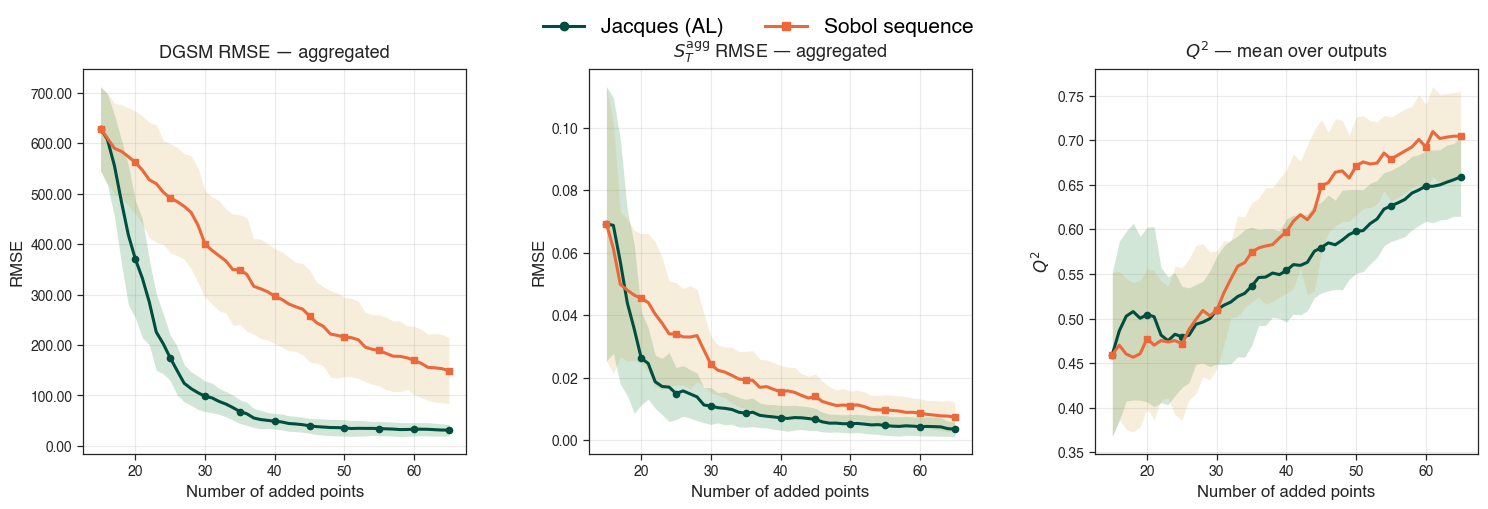

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                           gridspec_kw={"wspace": 0.32})

ax = axes[0]
_band(ax, x_axis, dgsm_agg_j_mean, dgsm_agg_j_std, pal_jacques, pal_fill_j, "o")
_band(ax, x_axis, dgsm_agg_s_mean, dgsm_agg_s_std, pal_sobol,   pal_fill_s, "s")
_style(ax, r"DGSM RMSE — aggregated", "RMSE", show_xlabel=True, fontsize = 12)

ax = axes[1]
_band(ax, x_axis, st_agg_j_mean, st_agg_j_std, pal_jacques, pal_fill_j, "o")
_band(ax, x_axis, st_agg_s_mean, st_agg_s_std, pal_sobol,   pal_fill_s, "s")
_style(ax, r"$S_T^{\mathrm{agg}}$ RMSE — aggregated", "RMSE", show_xlabel=True, fontsize=12)

ax = axes[2]
_band(ax, x_axis, q2_j_mean, q2_j_std, pal_jacques, pal_fill_j, "o")
_band(ax, x_axis, q2_s_mean, q2_s_std, pal_sobol,   pal_fill_s, "s")
_style(ax, r"$Q^2$ — mean over outputs", r"$Q^2$", show_xlabel=True, fontsize=12)

handles = [
    plt.Line2D([0], [0], color=pal_jacques, marker="o", lw=2.2, label="Jacques (AL)"),
    plt.Line2D([0], [0], color=pal_sobol,   marker="s", lw=2.2, label="Sobol sequence"),
]
fig.legend(handles=handles, loc="upper center", ncol=2,
            bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=15)

If you have any questions you can contact me : FIRST_NAME.LAST_NAME [at] ec-lyon.fr

If you dive into the raw codes, you may see some different choice of typo, this is normal, it is a code that was sequentially improved over the past 2 years. But, I hope to have time to check everything one day 🤧 (promise ?).

It is a simple notebook, the full codes around my PhD thesis will be available in this **[REPO](https://github.com/gulambert/ActiveDGSM)**

